In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("../data/processed/clean_employebility.csv")
df.head()

,gender,tenth_board,tenth_marks,twelfth_board,twelfth_marks,Stream,cgpa,cgpa_category,internship,training,has_backlogs,project,communication_score,communication,technical_score,skill_score,placement
0,Female,State Board,96.7,CBSE,70.2,Mechanical Engineering,7.37,Average,0,1,0,0,3,Average,1,5,0
1,Female,WBBSE,96.2,WBCHSE,90.6,Electronics and Communication Engineering,9.35,High,0,0,0,1,4,Good,0,5,0
2,Male,State Board,97.5,CBSE,69.6,Information Technology,7.84,High,0,1,0,1,3,Average,1,6,1
3,Female,CBSE,96.9,Other state Board,77.6,Computer Science in AIML,7.87,High,1,0,1,1,2,Below Average,1,5,0
4,Female,ICSE,99.1,CBSE,62.8,Computer Science and Engineering,9.26,High,1,1,0,1,1,Poor,1,5,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               401 non-null    object 
 1   tenth_board          401 non-null    object 
 2   tenth_marks          401 non-null    float64
 3   twelfth_board        401 non-null    object 
 4   twelfth_marks        401 non-null    float64
 5   Stream               401 non-null    object 
 6   cgpa                 401 non-null    float64
 7   cgpa_category        401 non-null    object 
 8   internship           401 non-null    int64  
 9   training             401 non-null    int64  
 10  has_backlogs         401 non-null    int64  
 11  project              401 non-null    int64  
 12  communication_score  401 non-null    int64  
 13  communication        401 non-null    object 
 14  technical_score      401 non-null    int64  
 15  skill_score          401 non-null    int

In [9]:
df.duplicated().sum()

np.int64(0)

### Correlation

In [13]:
df[['cgpa','skill_score','communication_score','placement']].corr()

,cgpa,skill_score,communication_score,placement
cgpa,1.000000,-0.057661,-0.146818,0.037593
skill_score,-0.057661,1.000000,0.815630,0.204425
communication_score,-0.146818,0.815630,1.000000,-0.045689
placement,0.037593,0.204425,-0.045689,1.000000


### 1. CGPA vs Placement

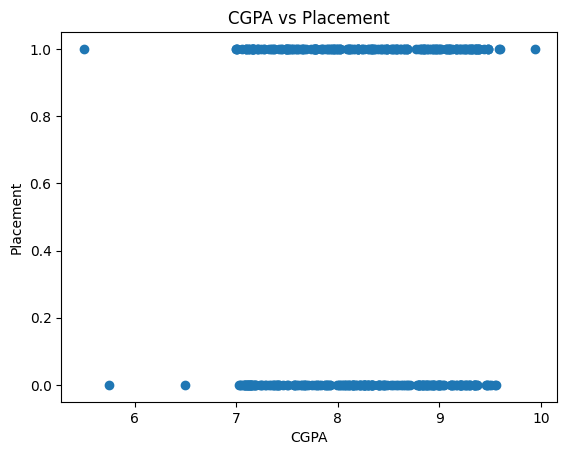

In [15]:
plt.scatter(df['cgpa'], df['placement'])
plt.xlabel("CGPA")
plt.ylabel("Placement")
plt.title("CGPA vs Placement")
plt.show()

### 2.Skill Score vs Placement

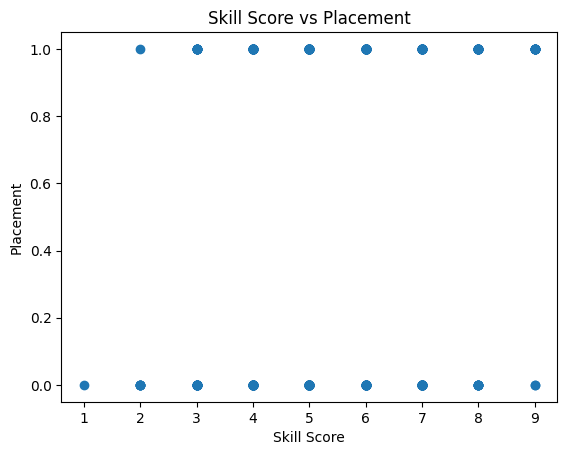

In [16]:
plt.scatter(df['skill_score'], df['placement'])
plt.xlabel("Skill Score")
plt.ylabel("Placement")
plt.title("Skill Score vs Placement")
plt.show()

In [20]:
df[(df['skill_score'] == 9) & (df['placement'] == 1)]

,gender,tenth_board,tenth_marks,twelfth_board,twelfth_marks,Stream,cgpa,cgpa_category,internship,training,has_backlogs,project,communication_score,communication,technical_score,skill_score,placement
16,Female,WBBSE,89.8,CBSE,88.6,Computer Science and Engineering,7.66,High,1,1,0,1,5,Excellent,1,9,1
22,Male,ICSE,76.9,CBSE,68.2,Electrical Engineering,8.10,High,1,1,0,1,5,Excellent,1,9,1
99,Female,WBBSE,88.2,ISE,71.5,Electronics and Communication Engineering,9.10,High,1,1,0,1,5,Excellent,1,9,1
112,Male,WBBSE,72.0,CBSE,64.4,Information Technology,8.33,High,1,1,0,1,5,Excellent,1,9,1
153,Male,ICSE,76.3,CBSE,81.8,Information Technology,9.07,High,1,1,0,1,5,Excellent,1,9,1
181,Male,State Board,95.4,CBSE,79.0,Chemical Engineering,7.96,High,1,1,0,1,5,Excellent,1,9,1
247,Male,CBSE,85.9,ISE,76.9,Electronics and Communication Engineering,8.85,High,1,1,0,1,5,Excellent,1,9,1
264,Female,State Board,70.5,WBCHSE,63.9,Electronics and Communication Engineering,7.54,High,1,1,0,1,5,Excellent,1,9,1
271,Female,CBSE,93.2,CBSE,89.0,Civil Engineering,8.13,High,1,1,0,1,5,Excellent,1,9,1
285,Female,ICSE,85.0,CBSE,87.7,Computer Science and Engineering,8.20,High,1,1,0,1,5,Excellent,1,9,1


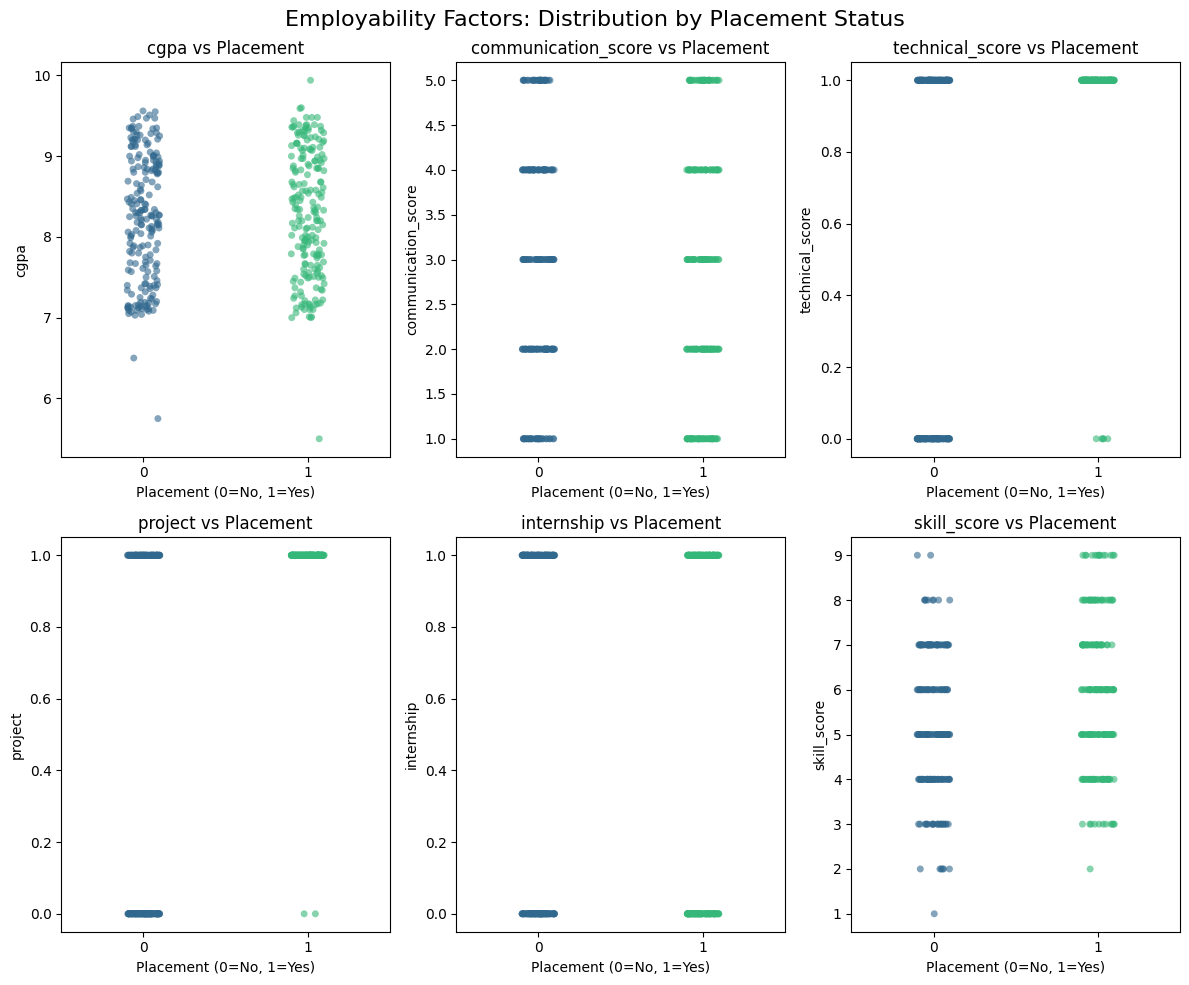

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
fig.suptitle('Employability Factors: Distribution by Placement Status', fontsize=16)

# List of features to plot
features = ['cgpa', 'communication_score', 'technical_score', 'project', 'internship','skill_score']

for i, col in enumerate(features):
    row = i // 3
    pos = i % 3
    sns.stripplot(ax=axes[row, pos], 
                  x='placement', 
                  y=col, 
                  data=df, 
                  palette='viridis',
                  hue='placement',
                  legend=False,
                  jitter=True,        # spreads points so they don't overlap
                  alpha=0.6)          # transparency
    axes[row, pos].set_title(f'{col} vs Placement')
    axes[row, pos].set_xlabel('Placement (0=No, 1=Yes)')

# Hide the empty 6th subplot
#axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

In [32]:
#Calculate the Correlation Matrix
cols = ['cgpa', 'communication_score', 'technical_score', 'project', 'internship', 'placement']
corr_matrix = df[cols].corr()

In [33]:
corr_matrix

,cgpa,communication_score,technical_score,project,internship,placement
cgpa,1.000000,-0.146818,0.014476,0.049140,0.236167,0.037593
communication_score,-0.146818,1.000000,-0.030628,-0.016957,-0.023037,-0.045689
technical_score,0.014476,-0.030628,1.000000,0.322563,-0.005529,0.482272
project,0.049140,-0.016957,0.322563,1.000000,-0.023351,0.568463
internship,0.236167,-0.023037,-0.005529,-0.023351,1.000000,-0.016562
placement,0.037593,-0.045689,0.482272,0.568463,-0.016562,1.000000


>> “While several skill-related variables show positive correlation with placement, only project and technical skills demonstrate moderate predictive strength. Academic performance (CGPA) shows negligible impact, and no single variable alone guarantees employability.”
